# Phase 3: Descriptive Analysis and Visualization

### Step 1: Descriptive Statistics
We calculate the mean, mode, variance, and standard deviation for our key variables to understand the central tendency and dispersion of the data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('../data/processed/final_dengue_weather.csv')
df_eng = pd.read_csv('../data/processed/engineered_dengue_weather.csv')

stats_cols = ['Dengue_Cases', 'rfh', 'rfh_avg']
stats = df_raw[stats_cols].agg(['mean', 'var', 'std'])
stats.loc['mode'] = df_raw[stats_cols].mode().iloc[0]

display(stats)

,Dengue_Cases,rfh,rfh_avg
mean,1.124926e+03,221.310744,75.760547
var,2.764268e+06,23930.053422,1599.894347
std,1.662609e+03,154.693418,39.998679
mode,2.070000e+02,3.471831,2.222848


### Step 2: Frequency and Distribution
We visualize the distribution of Dengue cases using a histogram and Kernel Density Estimate (KDE) to identify skewness and the frequency of high-case months.

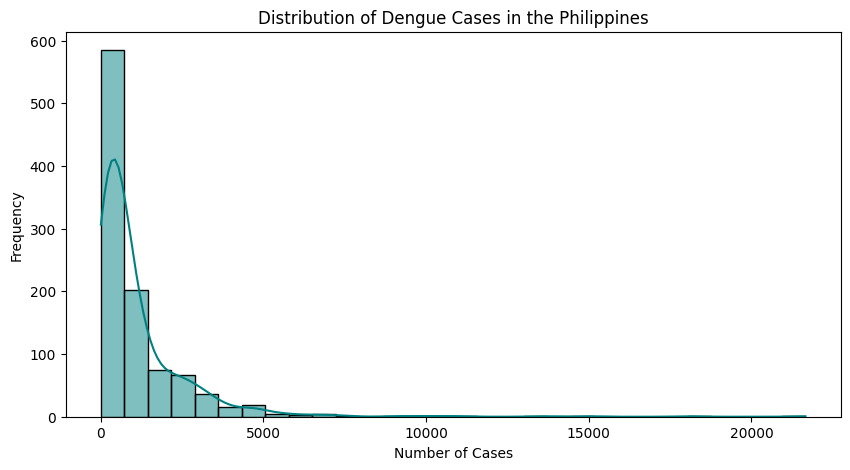

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df_raw['Dengue_Cases'], kde=True, color='teal', bins=30)
plt.title('Distribution of Dengue Cases in the Philippines')
plt.xlabel('Number of Cases')
plt.ylabel('Frequency')
plt.show()

### Step 3: Trends Over Time
We aggregate the cases by date to visualize the seasonal fluctuations and identify years with significant outbreaks.

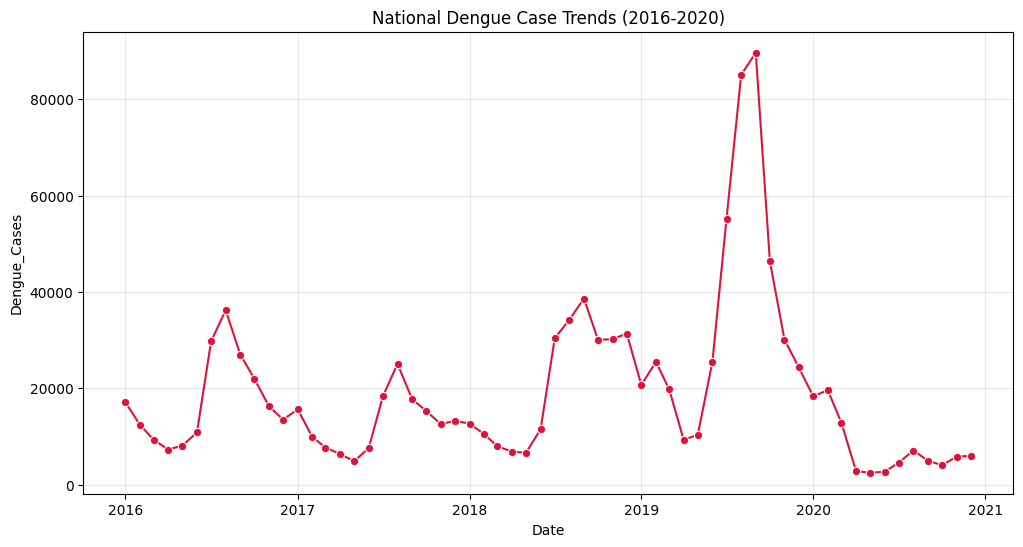

In [4]:
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
timeline = df_raw.groupby('Date')['Dengue_Cases'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=timeline, x='Date', y='Dengue_Cases', marker='o', color='crimson')
plt.title('National Dengue Case Trends (2016-2020)')
plt.grid(True, alpha=0.3)
plt.show()

### Step 4: Categorical Comparisons
Using a boxplot, we compare Dengue distribution across different regions to identify which areas are most prone to high case volumes and outliers.

C:\Users\BUENVIAJE\AppData\Local\Temp\ipykernel_101472\2179245345.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='Region', y='Dengue_Cases', palette='Set2')


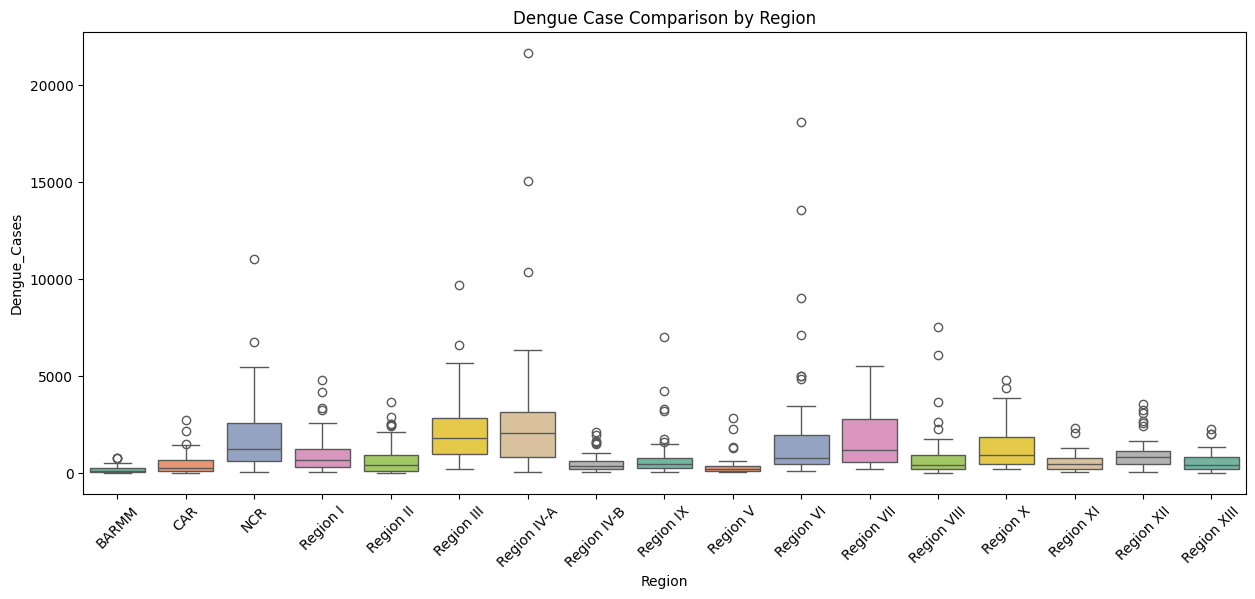

In [5]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_raw, x='Region', y='Dengue_Cases', palette='Set2')
plt.xticks(rotation=45)
plt.title('Dengue Case Comparison by Region')
plt.show()

### Step 5: Relationships and Correlations
We use a scatter plot to observe the relationship between rainfall and cases, followed by a heatmap of our engineered features to identify the strongest predictors for our models.

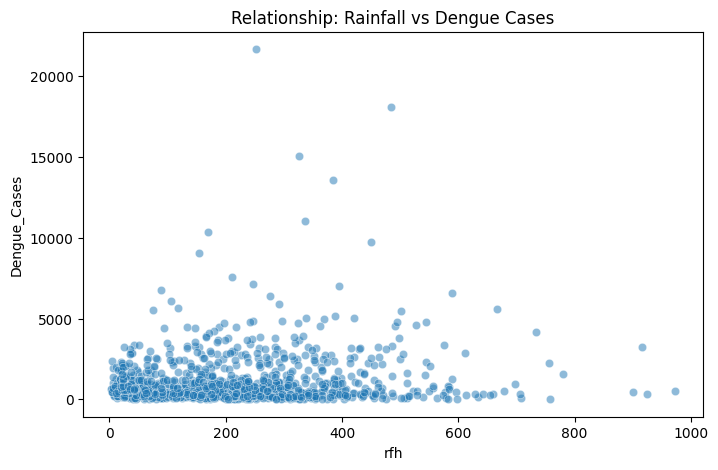

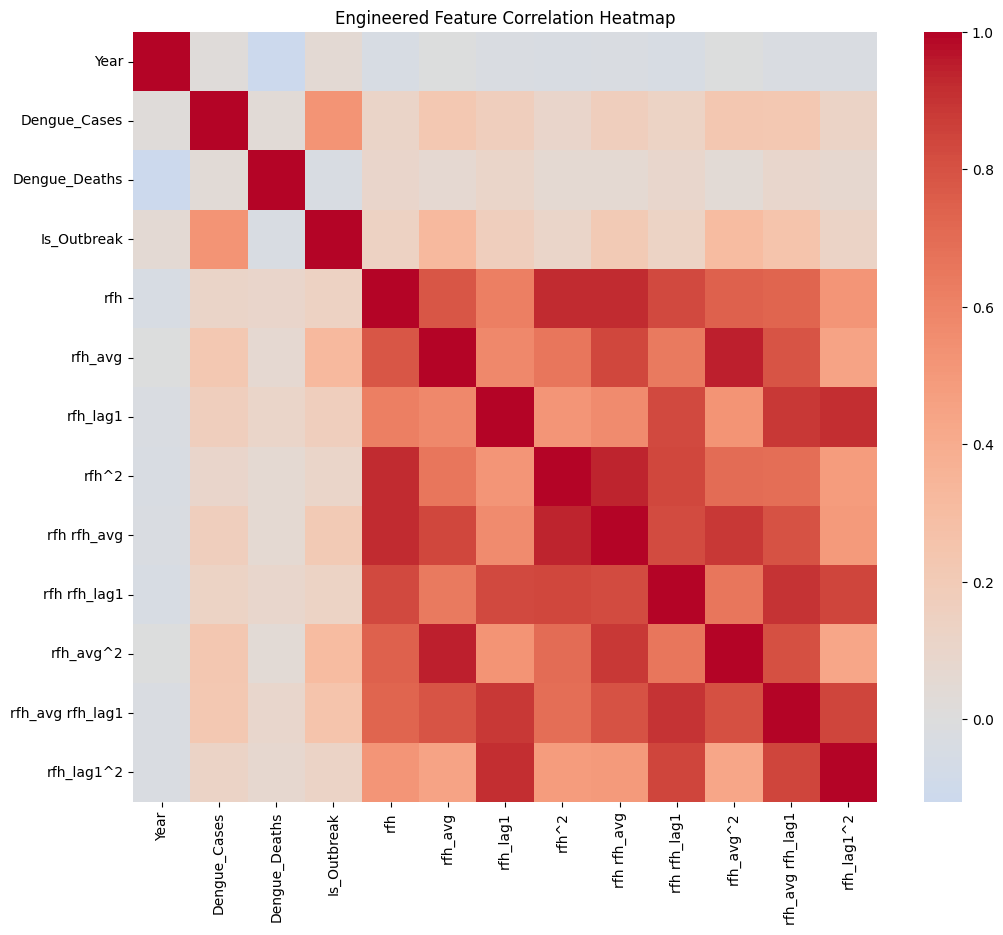

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_raw, x='rfh', y='Dengue_Cases', alpha=0.5)
plt.title('Relationship: Rainfall vs Dengue Cases')
plt.show()

plt.figure(figsize=(12, 10))
correlation_matrix = df_eng.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Engineered Feature Correlation Heatmap')
plt.show()